In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask, CFDViT
from matplotlib.ticker import FormatStrFormatter
from tqdm import tqdm

from config import *

from Data.dataset_cfd import *
from model.lr_scheduler import *
from config import *
from model import load_checkpoint

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr

import json
import os

import cv2

from training import predict_field

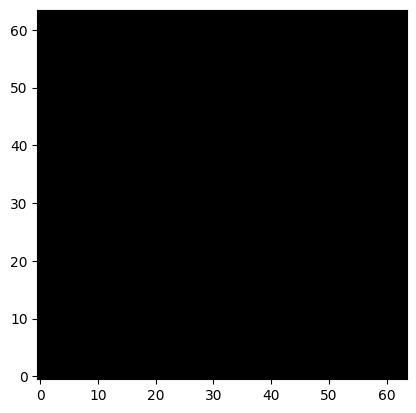

In [3]:
# Create grid

newer_df = pd.read_csv("../Data/Problems/Lid_Driven_domain/Re_8.43.csv", index_col=0)

xi = np.linspace(0, 1, GRID_SIZE)
yi = np.linspace(0, 1, GRID_SIZE)

x = newer_df["x"].values
y = newer_df["y"].values
u = newer_df["u (m/s)"].values


X, Y = np.meshgrid(xi, yi)

mask = np.array(newer_df['mask']).reshape(64, 64).astype("float32")
# mask = 1 - mask.astype(int)
# mask = np.roll(mask, 10, axis=0)
plt.imshow(mask, origin="lower", cmap="gray")

In [4]:
transformer = CFDViT(
                      d_model        = 768,
                      N              = N,
                      num_heads      = NUM_HEADS,
                      d_ff           = D_FF,
                      patch_dim      = PATCH_DIM-FOURIER_DIMENSIONS)

In [5]:
# load_checkpoint("checkpoint_lid_VIT.pt", transformer)
load_checkpoint("../model_checkpoints/Lid_Driven.pt", transformer)

999

In [6]:
params = sum(p.numel() for p in transformer.parameters())
print(f"Total parameters: {params:,}")

Total parameters: 27,347,136


In [7]:
def fourier_features(cords: torch.tensor, num_freq = FOURIER_FEATURES):
    # [num_patches, 2] -> [num_patches, num_freq * 2]
    freqs = 2 ** torch.linspace(0, num_freq - 1, num_freq)                   # [num_freqs]
    angles = (cords.unsqueeze(-1) * freqs  * torch.pi)                       # [num_patches, 2, num_freq]
    encoded = torch.cat([torch.sin(angles), torch.cos(angles)], dim = -1)    # [num_patches, 2, num_freq * 2]
    return encoded.view(cords.shape[0], -1)                                  # [num_patches, 2 * num_freq * 2]


patches_per_side = GRID_SIZE // PATCH_SIZE
coords = []
for row in range(patches_per_side):
    for col in range(patches_per_side):
        coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
coords_tensor = torch.tensor(coords, dtype=torch.float32)


In [8]:
with open("../model_checkpoints/Lid_Driven_train_test_re.json", "r", encoding="utf-8") as file:
    train_test_re = json.load(file)

In [9]:
pre_train_re  = sorted([float(i.split('.csv')[0].split("Re_")[-1]) for i in os.listdir("../Data/Problems/Lid_Driven_domain")])
post_train_re = sorted(train_test_re['test_re'] + train_test_re['train_re'])
pre_train_re[:5]

[8.43, 16.76, 20.0, 25.09, 33.42]

In [17]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, C, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(C, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled


def sharpen_bilateral(field):
    field = field.astype(np.float32)

    mn, mx = field.min(), field.max()
    img = (field - mn) / (mx - mn + 1e-8)

    img = cv2.bilateralFilter(img, 9, 0.08, 7)

    return img * (mx - mn) + mn

def predict(re_value, model, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size, patch_size, mask,
            device="cpu", plot: bool = True, sharpen: bool = False):
    '''
    magic
    '''

    # normalize using dataset stats
    re_norm = (re_value - re_mean) / re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

 
    pred_patches = predict_field(model, src)


    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0],
                                   grid_size // patch_size,
                                   patch_size,
                                   grid_size)


    u = unrolled[0].detach().cpu() * mask
    v = unrolled[1].detach().cpu() * mask
    P = unrolled[2].detach().cpu() * mask

    # denormalize
    u = (u * u_std) + u_mean
    v = (v * v_std) + v_mean
    P = (P * P_std) + P_mean

    if sharpen:
        u = sharpen_bilateral(u.numpy())
        v = sharpen_bilateral(v.numpy())
        P = sharpen_bilateral(P.numpy())

    # numerical gradients
    u_np = u
    v_np = v

    du_dx = np.gradient(u_np, axis = 1) # derivative along x (cols)
    du_dy = np.gradient(u_np, axis = 0)
    dv_dy = np.gradient(v_np, axis = 0) # derivative along y (rows)
    dv_dx = np.gradient(v_np, axis = 1)

    d2u_dx2 = np.gradient(du_dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, axis = 1)

    dP_dx = np.gradient(P, axis = 1)
    dP_dy = np.gradient(P, axis = 0)



    momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

    momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

    divergence = du_dx + dv_dy

    mag = np.sqrt(u**2 + v**2)

    if plot:
    
        # plot
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)


        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        # u
        c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        # v
        c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        # p
        c2 = axes[2].contourf(x_grid, y_grid, P, levels=300, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        # mag
        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
        fig.colorbar(c3, ax=axes[3])
        axes[3].set_title("|U|")# + streamlines")


        c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, P, divergence, momentum_res, mag


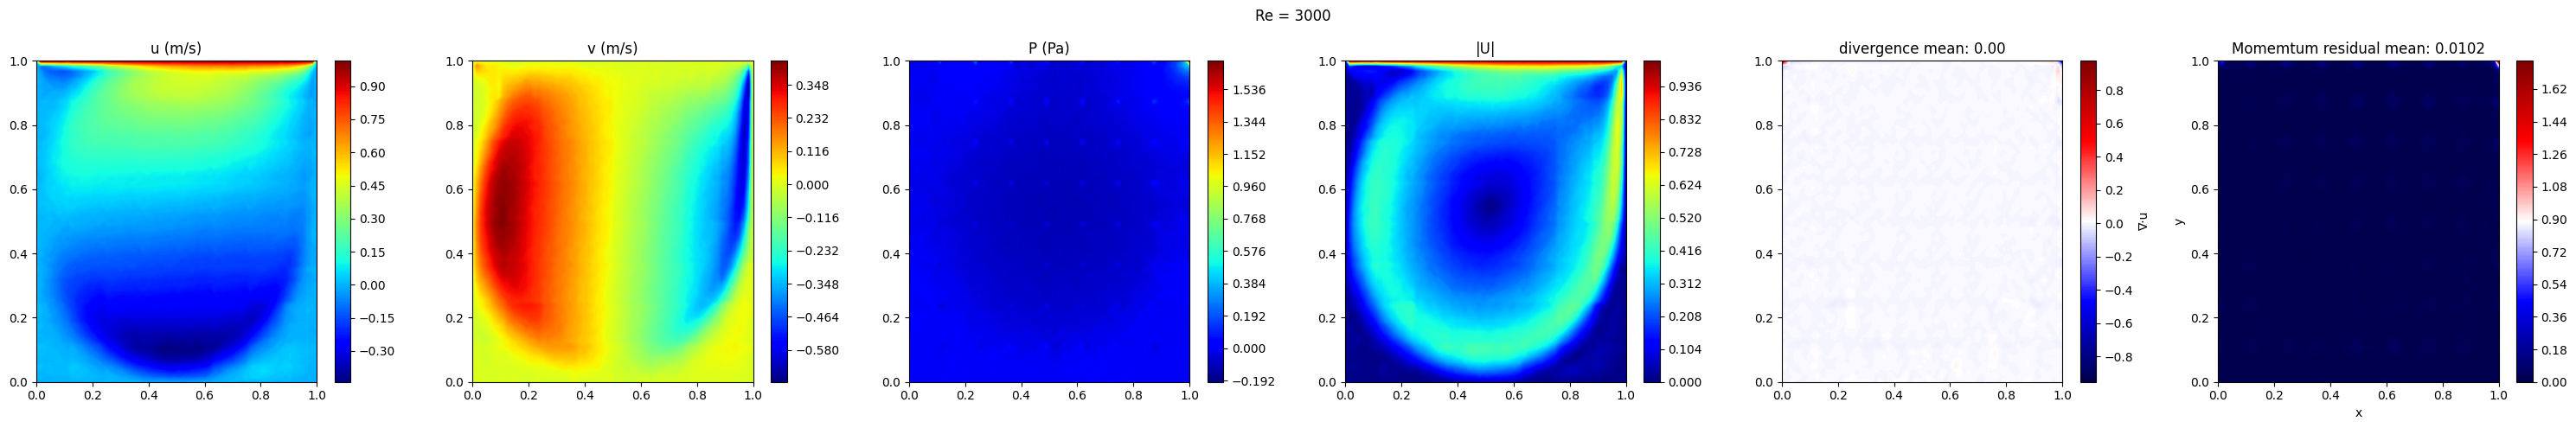

In [18]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 3000, model = transformer, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = GRID_SIZE, patch_size = PATCH_SIZE, mask = mask,
                                   device = "cpu", plot = True
                                   )

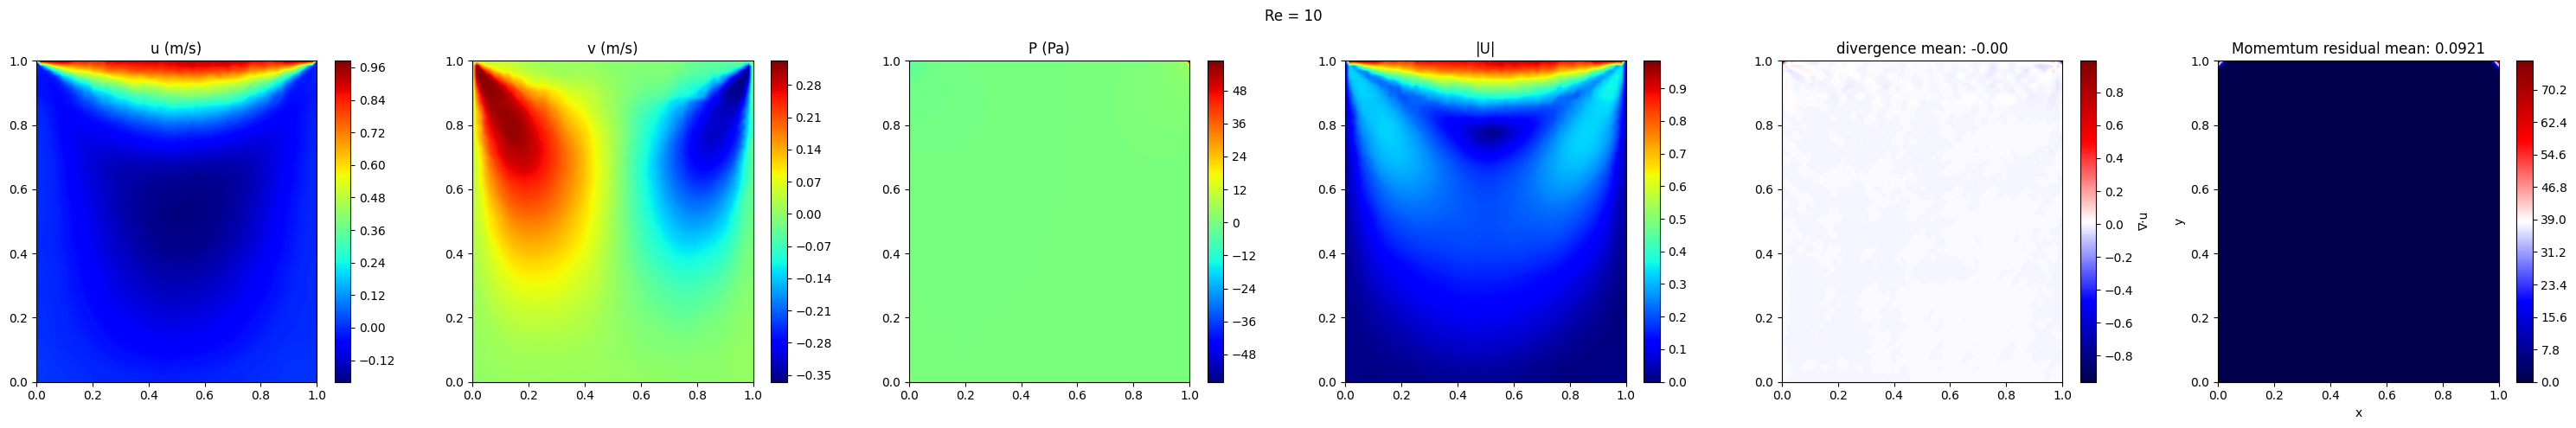

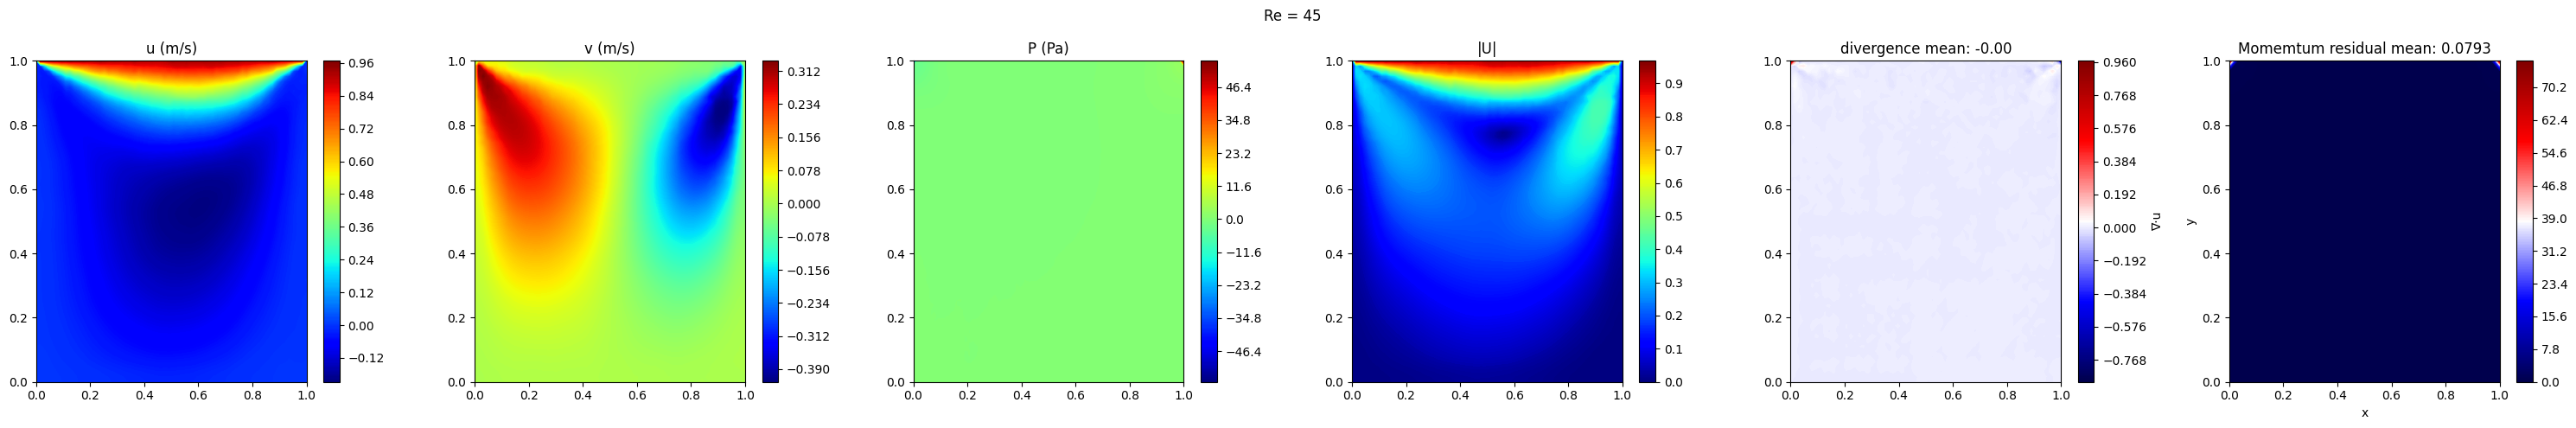

In [20]:
u_1, v_1, P_1, divergence_1, momentum_res_1, mag_1 = predict(re_value = 10, model = transformer, 
                                                             re_mean = RE_MEAN, re_std = RE_STD, 
                                                             u_mean = U_MEAN,   u_std = U_STD, 
                                                             v_mean = V_MEAN,   v_std = V_STD, 
                                                             P_mean = P_MEAN,   P_std = P_STD,
                                                             grid_size = GRID_SIZE, patch_size = PATCH_SIZE, mask = mask,
                                                             device = "cpu", plot = True, sharpen = True
                                                             )
                             
u_2, v_2, P_2, divergence_2, momentum_res_2, mag_2 = predict(re_value = 45, model = transformer, 
                                                             re_mean = RE_MEAN, re_std = RE_STD, 
                                                             u_mean = U_MEAN,   u_std = U_STD, 
                                                             v_mean = V_MEAN,   v_std = V_STD, 
                                                             P_mean = P_MEAN,   P_std = P_STD,
                                                             grid_size = GRID_SIZE, patch_size = PATCH_SIZE, mask = mask,
                                                             device = "cpu", plot = True, sharpen = True
                                                             )

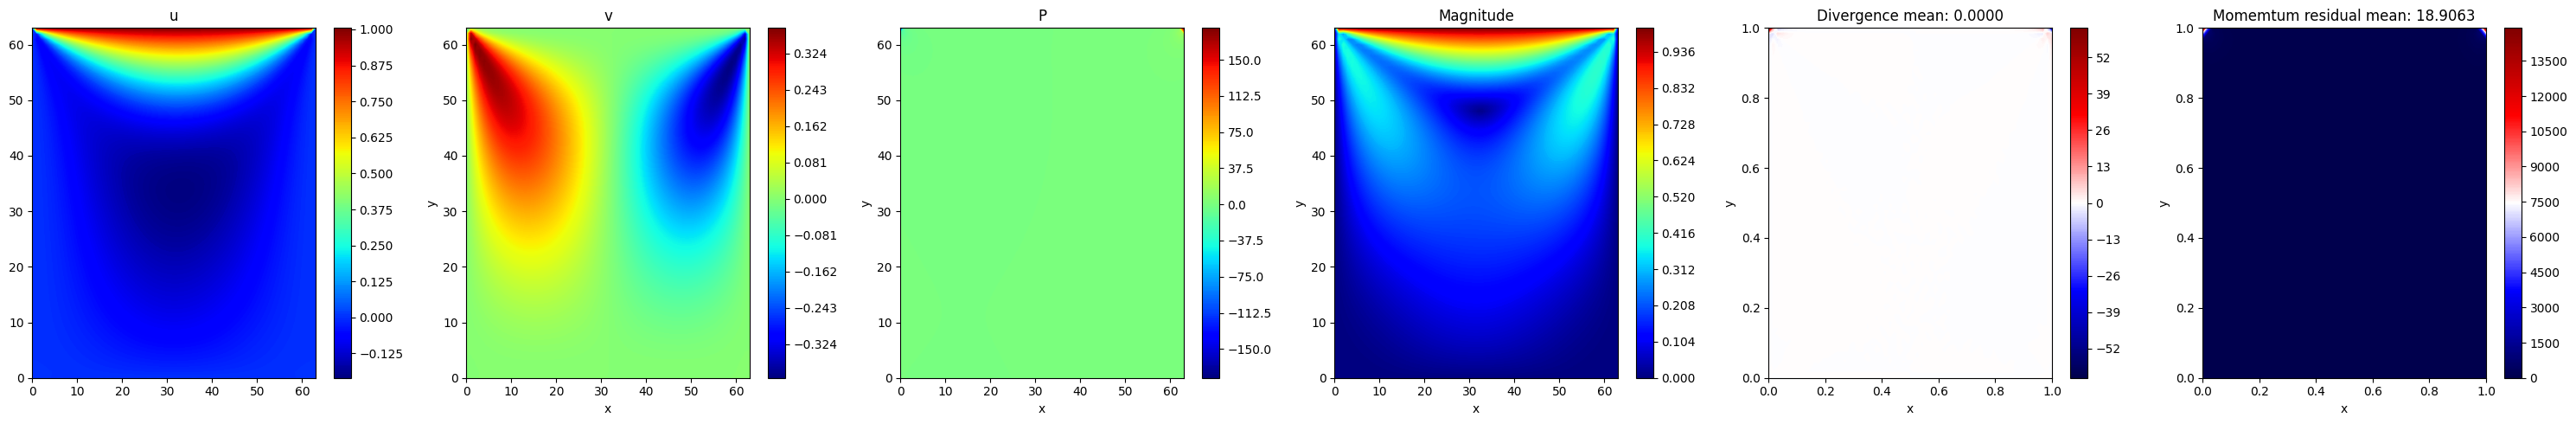

In [21]:
def ground_truth(re: float, plot: bool):
    lisdir = os.listdir("../Data/Problems/Lid_Driven_domain")
    assert f"Re_{re}.csv" or f"Re_{float(re)}.csv" in lisdir, f"{re}: make sure re is in the csv folder"

    if f"Re_{float(re)}.csv" in lisdir:
        re = float(re)

    df = pd.read_csv(f"../Data/Problems/Lid_Driven_domain/Re_{re}.csv", index_col = 0)

    lin = np.linspace(0, 1, 64)

    df = df.dropna(subset=["x", "y", "u (m/s)", "v (m/s)", "p (Pa)"])

    x = df['x']
    y = df['y']
    u = df["u (m/s)"].values.astype(np.float32)
    v = df["v (m/s)"].values.astype(np.float32)
    P = df["p (Pa)"].values.astype(np.float32)

    points = np.stack([x, y], axis=1)  # (N, 2)
    # interpolate u and v onto regular grid

    grid_x, grid_y = np.meshgrid(lin, lin) # (grid_size, grid_size)

    u_grid = griddata(points, u, (grid_x, grid_y), method="linear", fill_value=0.0)
    v_grid = griddata(points, v, (grid_x, grid_y), method="linear", fill_value=0.0)
    P_grid = griddata(points, P, (grid_x, grid_y), method="linear", fill_value=0.0)

    dx = lin[1] - lin[0]
    dy = lin[1] - lin[0]

    # gradients
    du_dx = np.gradient(u_grid, dx, axis = 1)
    du_dy = np.gradient(u_grid, dy, axis = 0)
    dv_dy = np.gradient(v_grid, dy, axis = 0)
    dv_dx = np.gradient(v_grid, dx, axis = 1)

    d2u_dx2 = np.gradient(du_dx, dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, dx, axis = 1)

    dP_dx = np.gradient(P_grid, dx, axis = 1)
    dP_dy = np.gradient(P_grid, dy, axis = 0)

    # divergence
    div = du_dx + dv_dy

    # momentum residual
    # import pdb; pdb.set_trace()
    momentum_res_x = (1 * ((u_grid * du_dx) + (v_grid * du_dy))) + dP_dx + (1/re) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u_grid * dv_dx) + (v_grid * dv_dy))) + dP_dy + (1/re) * (d2v_dx2 + d2v_dy2)

    momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5


    mag = np.sqrt(u_grid**2 + v_grid**2)
    
    if plot:
        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        # u
        u_c = axes[0].contourf(u_grid, levels=300, cmap="jet")
        plt.colorbar(u_c, ax=axes[0])
        axes[0].set_title("u")

        # v
        v_c = axes[1].contourf(v_grid, levels=300, cmap="jet")
        plt.colorbar(v_c, ax=axes[1])
        axes[1].set_title("v")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")

        # P
        p_c = axes[2].contourf(P_grid, levels=300, cmap="jet")
        plt.colorbar(p_c, ax=axes[2])
        axes[2].set_title("P")
        axes[2].set_xlabel("x")
        axes[2].set_ylabel("y")

        # mag
        mag_c = axes[3].contourf(mag, levels=300, cmap="jet")
        plt.colorbar(mag_c, ax=axes[3])
        axes[3].set_title("Magnitude")
        axes[3].set_xlabel("x")
        axes[3].set_ylabel("y")

        # div
        div_c = axes[4].contourf(grid_x, grid_y, div, levels=300, cmap="seismic")
        plt.colorbar(div_c, ax=axes[4])
        axes[4].set_title(f"Divergence mean: {div.mean():.4f}")
        axes[4].set_xlabel("x")
        axes[4].set_ylabel("y")

        div_m = axes[5].contourf(grid_x, grid_y, momentum_res, levels=300, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.tight_layout()
        plt.show()
    
    return u_grid, v_grid, P_grid, div, momentum_res, mag

u_grid, v_grid, P_grid, div, momentum_res, mag = ground_truth(re = 8.43, plot=True)

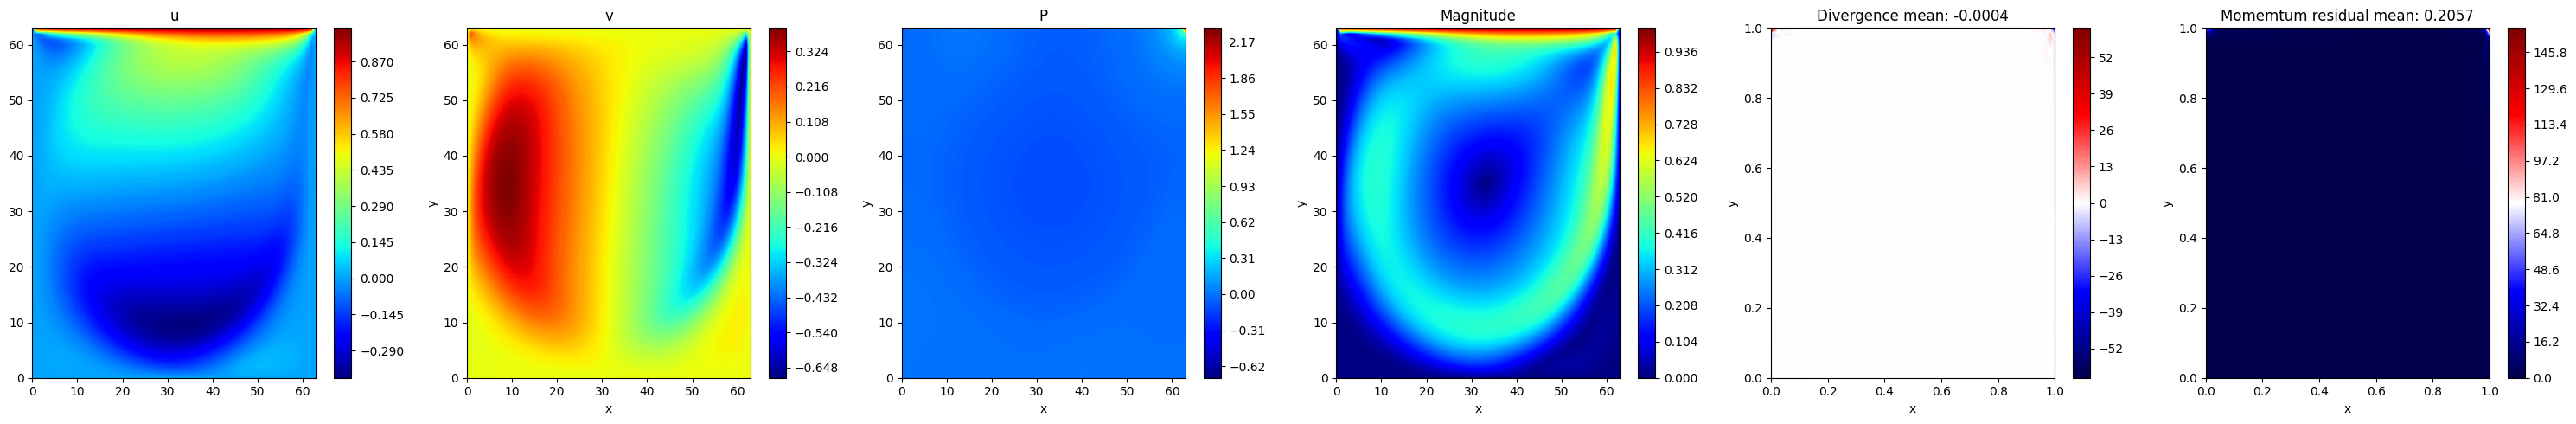

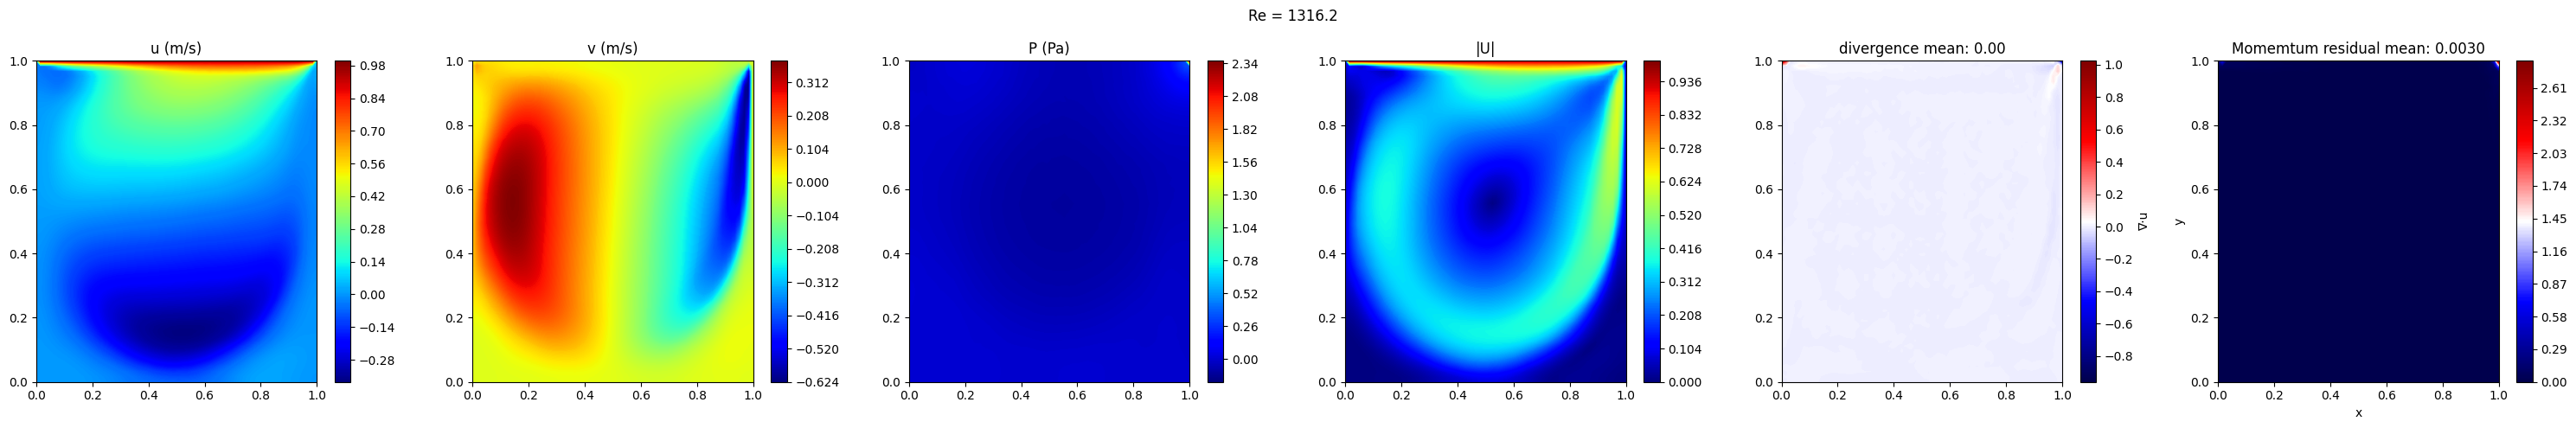

In [23]:
re = 1316.2
u_grid_actual, v_grid_actual, P_grid, div_actual, momentum_res_actual, mag_actual = ground_truth(re = re, plot=True)

u_pred, v_pred, P_pred, div_pred, momentum_res_pred, mag_pred = predict(re_value = re, model = transformer, 
                                                     u_mean = U_MEAN,   u_std = U_STD, 
                                                     re_mean = RE_MEAN, re_std = RE_STD, 
                                                     v_mean = V_MEAN,   v_std = V_STD, 
                                                     P_mean = P_MEAN,   P_std = P_STD,
                                                     grid_size = GRID_SIZE, patch_size = PATCH_SIZE, mask = mask,
                                                     device = "cpu", plot = True, sharpen = True
                                                     )

In [26]:
import imageio.v2 as imageio

errors = {}
frames = []

with imageio.get_writer("../renders/Lid_Driven.mp4", fps=15) as writer:
    for re_idx in tqdm(range(len(pre_train_re))):

        re = pre_train_re[re_idx]
        if re.is_integer():
            re = int(re)

        err = {}

        u_grid_actual, v_grid_actual, p_grid_actual, div_actual, momentum_res_actual, mag_actual = ground_truth(
            re=re,
            plot=False
        )

        u_grid_pred, v_grid_pred, p_grid_pred, div_pred, momentum_res_pred, mag_pred = predict(
            re_value=re,
            model=transformer,
            re_mean=RE_MEAN,
            re_std=RE_STD,
            u_mean=U_MEAN,
            u_std=U_STD,
            v_mean=V_MEAN,
            v_std=V_STD,
            P_mean=P_MEAN,
            P_std=P_STD,
            grid_size=GRID_SIZE,
            patch_size=PATCH_SIZE,
            mask = mask,
            device="cpu",
            plot=False,
            sharpen=True
        )

        u_grid_pred       = np.array(u_grid_pred)
        v_grid_pred       = np.array(v_grid_pred)
        p_grid_pred       = np.array(p_grid_pred)
        mag_pred          = np.array(mag_pred)
        div_pred          = np.array(div_pred)
        momentum_res_pred = np.array(momentum_res_pred)

        
        bool_mask = mask.astype(bool)

        # U
        u_difference = np.abs(u_grid_actual - u_grid_pred)
        u_rmse = np.sqrt(((u_grid_actual[bool_mask] - u_grid_pred[bool_mask]) ** 2).mean())

        # V
        v_difference = np.abs(v_grid_actual - v_grid_pred)
        v_rmse = np.sqrt(((v_grid_actual[bool_mask] - v_grid_pred[bool_mask]) ** 2).mean())

        # Pressure
        p_difference = np.abs(p_grid_actual - p_grid_pred)
        p_rmse = np.sqrt(((p_grid_actual[bool_mask] - p_grid_pred[bool_mask]) ** 2).mean())

        # Velocity magnitude
        mag_difference = np.abs(mag_actual - mag_pred)
        mag_rmse = np.sqrt(((mag_actual[bool_mask] - mag_pred[bool_mask]) ** 2).mean())

        # Divergence
        div_difference = np.abs(div_actual - div_pred)
        div_rmse = np.sqrt(((div_actual[bool_mask] - div_pred[bool_mask]) ** 2).mean())

        # Momentum residual
        mom_difference = np.abs(momentum_res_actual - momentum_res_pred)
        mom_rmse = np.sqrt(((momentum_res_actual[bool_mask] - momentum_res_pred[bool_mask]) ** 2).mean())

        err["u_error"]   = u_rmse.item()
        err["v_error"]   = v_rmse.item()
        err["p_error"]   = p_rmse.item()
        err["mag_error"] = mag_rmse.item()
        err["div_error"] = div_rmse.item()
        err["div_error"] = mom_rmse.item()
        err["isTrain"]   = True if post_train_re[re_idx] in train_test_re['train_re'] else False

        errors[re] = err

        fig, axes = plt.subplots(6, 3, figsize=(16, 28))

        lin = torch.linspace(0, 1, 64)

        ####################################################################
        # U
        ####################################################################
        c = axes[0, 0].contourf(lin, lin,  np.where(bool_mask, u_grid_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[0, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[0, 0].set_title("U Actual")

        c = axes[0, 1].contourf(lin, lin, np.where(bool_mask, u_grid_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[0, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[0, 1].set_title("U Prediction")

        c = axes[0, 2].contourf(lin, lin, np.where(bool_mask, u_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[0, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[0, 2].set_title(f"|U Error|\nRMSE={u_rmse:.4f} | Mean={np.abs(u_grid_actual[bool_mask] - u_grid_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # V
        ####################################################################
        c = axes[1, 0].contourf(lin, lin, np.where(bool_mask, v_grid_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[1, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[1, 0].set_title("V Actual")

        c = axes[1, 1].contourf(lin, lin, np.where(bool_mask, v_grid_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[1, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[1, 1].set_title("V Prediction")

        c = axes[1, 2].contourf(lin, lin, np.where(bool_mask, v_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[1, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[1, 2].set_title(f"|V Error|\nRMSE={v_rmse:.4f} | Mean={np.abs(v_grid_actual[bool_mask] - v_grid_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # Pressure
        ####################################################################
        c = axes[2, 0].contourf(lin, lin, np.where(bool_mask, p_grid_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[2, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[2, 0].set_title("Pressure Actual")

        c = axes[2, 1].contourf(lin, lin, np.where(bool_mask, p_grid_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[2, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[2, 1].set_title("Pressure Prediction")

        c = axes[2, 2].contourf(lin, lin, np.where(bool_mask, p_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[2, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[2, 2].set_title(f"|Pressure Error|\nRMSE={p_rmse:.4f} | Mean={np.abs(mag_actual[bool_mask] - mag_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # Magnitude
        ####################################################################
        c = axes[3, 0].contourf(lin, lin, np.where(bool_mask, mag_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[3, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[3, 0].set_title("Magnitude Actual")

        c = axes[3, 1].contourf(lin, lin, np.where(bool_mask, mag_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[3, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[3, 1].set_title("Magnitude Prediction")

        c = axes[3, 2].contourf(lin, lin, np.where(bool_mask, mag_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[3, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[3, 2].set_title(f"|Magnitude Error|\nRMSE={mag_rmse:.4f} | Mean={np.abs(v_grid_actual[bool_mask] - v_grid_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # Divergence
        ####################################################################
        c = axes[4, 0].contourf(lin, lin, np.where(bool_mask, div_actual, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[4, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[4, 0].set_title(f"Actual Divergence\nMean={torch.tensor(div_actual[bool_mask]).mean():.4e}")

        c = axes[4, 1].contourf(lin, lin, np.where(bool_mask, div_pred, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[4, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[4, 1].set_title(f"Predicted Divergence\nMean={div_pred[bool_mask].mean():.4e}")

        c = axes[4, 2].contourf(lin, lin, np.where(bool_mask, div_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[4, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[4, 2].set_title(f"|Divergence Error|\nRMSE={div_rmse:.4e} | Mean={np.abs(div_actual[bool_mask] - div_pred[bool_mask]).mean():.4e}")
        
        
        ####################################################################
        # Momentum residual
        ####################################################################
        c = axes[5, 0].contourf(lin, lin, np.where(bool_mask, momentum_res_actual, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[5, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[5, 0].set_title(f"Actual Momentum Residual\nMean={torch.tensor(momentum_res_actual[bool_mask]).mean():.4e}")

        c = axes[5, 1].contourf(lin, lin, np.where(bool_mask, momentum_res_pred, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[5, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[5, 1].set_title(f"Predicted Momentum Residual\nMean={div_pred.mean():.4e}")

        c = axes[5, 2].contourf(lin, lin, np.where(bool_mask, mom_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[5, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[5, 2].set_title(f"|Divergence Error|\nRMSE={mom_rmse:.4e} | Mean={np.abs(momentum_res_actual[bool_mask] - momentum_res_pred[bool_mask]).mean():.4e}")


        plt.suptitle(f"Re = {re}", fontsize=18)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        
        fig.canvas.draw()
        frame = np.asarray(fig.canvas.renderer.buffer_rgba())
        # frames.append(frame)
        writer.append_data(frame)
        plt.close(fig)

        # plt.show()
        # break


100%|██████████| 320/320 [07:29<00:00,  1.40s/it] 


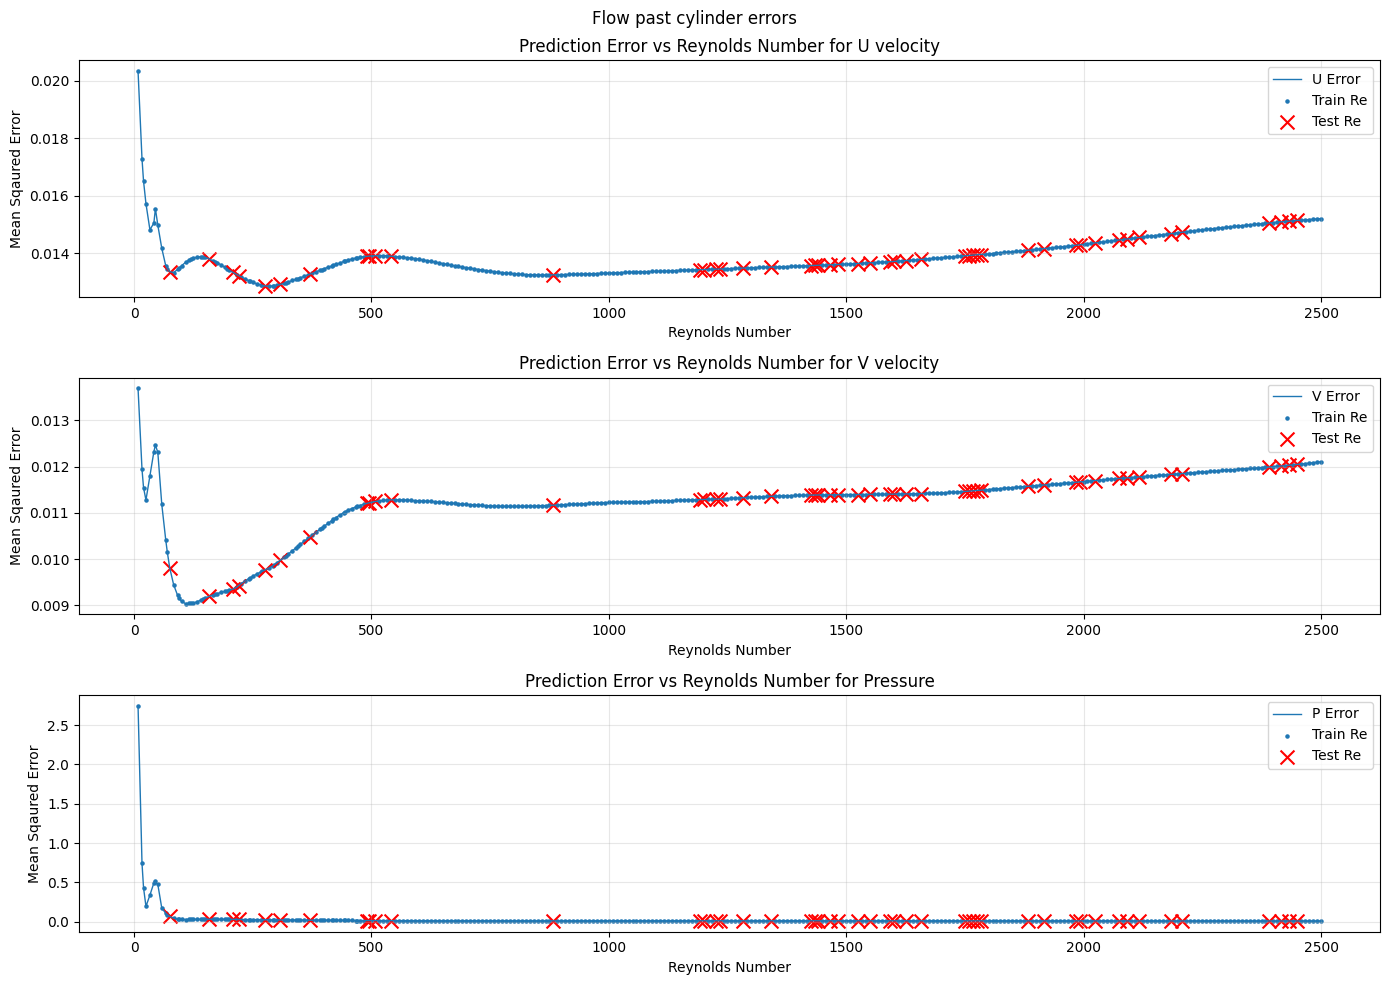

In [ ]:
df = pd.DataFrame(errors).T.reset_index()
df = df.rename(columns={"index": "Re"})
df = df.sort_values("Re")

train_df = df[df["isTrain"]]
test_df  = df[df['isTrain'] == False]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Lines
axes[0].plot(df["Re"], df["u_error"], label="U Error", linewidth=1)


# Train points
axes[0].scatter(
    train_df["Re"],
    train_df["u_error"],
    marker="o",
    s=5,
    label="Train Re",
    # color = "yellow"
)

# Test points
axes[0].scatter(
    test_df["Re"],
    test_df["u_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

axes[0].set_xlabel("Reynolds Number")
axes[0].set_ylabel("Mean Sqaured Error")
axes[0].set_title("Prediction Error vs Reynolds Number for U velocity")
axes[0].legend()

axes[0].grid(alpha=0.3)




axes[1].plot(df["Re"], df["v_error"], label="V Error", linewidth=1)

# Train points
axes[1].scatter(
    train_df["Re"],
    train_df["v_error"],
    marker="o",
    s=5,
    label="Train Re",
    # color = "yellow"
)

# Test points
axes[1].scatter(
    test_df["Re"],
    test_df["v_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

axes[1].set_xlabel("Reynolds Number")
axes[1].set_ylabel("Mean Sqaured Error")
axes[1].set_title("Prediction Error vs Reynolds Number for V velocity")
axes[1].legend()

axes[1].grid(alpha=0.3)




axes[2].plot(df["Re"], df["p_error"], label="P Error", linewidth=1)

# Train points
axes[2].scatter(
    train_df["Re"],
    train_df["p_error"],
    marker="o",
    s=5,
    label="Train Re",
    # color = "yellow"
)

# Test points
axes[2].scatter(
    test_df["Re"],
    test_df["p_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

axes[2].set_xlabel("Reynolds Number")
axes[2].set_ylabel("Mean Sqaured Error")
axes[2].set_title("Prediction Error vs Reynolds Number for Pressure")
axes[2].legend()

axes[2].grid(alpha=0.3)

fig.suptitle("Lid Driven errors")
plt.tight_layout()
plt.show()